# Evaluate armadillo

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "..")

import torch
import numpy as np
import trimesh

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Kaggle:
# ARMADILLO_PATH   = Path("/kaggle/input/your-dataset/modele/armadillo_small.obj")
# TEAPOT_PATH      = Path("/kaggle/input/your-dataset/modele/teapot.obj")
# ASIAN_DRAG_PATH  = Path("/kaggle/input/your-dataset/modele/asian_dragon_really_small.obj")
# CKPT_PATH        = Path("/kaggle/working/checkpoints/best_model.pt")

# Local:
ARMADILLO_PATH  = Path("../modele/armadillo_small.obj")
TEAPOT_PATH     = Path("../modele/teapot.obj")
ASIAN_DRAG_PATH = Path("../modele/asian_dragon_really_small.obj")
CKPT_PATH       = Path("checkpoints/best_model.pt")

print(f"Device       : {DEVICE}")
print(f"Armadillo    : {ARMADILLO_PATH}  (exists: {ARMADILLO_PATH.exists()})")
print(f"Teapot       : {TEAPOT_PATH}     (exists: {TEAPOT_PATH.exists()})")
print(f"Asian Dragon : {ASIAN_DRAG_PATH} (exists: {ASIAN_DRAG_PATH.exists()})")
print(f"Checkpoint   : {CKPT_PATH}       (exists: {CKPT_PATH.exists()})")

Device       : cpu
Armadillo    : ..\modele\armadillo_small.obj  (exists: True)
Teapot       : ..\modele\teapot.obj     (exists: True)
Asian Dragon : ..\modele\asian_dragon_really_small.obj (exists: True)
Checkpoint   : checkpoints\best_model.pt       (exists: True)


In [2]:
from armadillo.train import load_model

model = load_model(
    checkpoint_path    = str(CKPT_PATH),
    local_hidden_dims  = [64, 128],
    global_hidden_dims = [256, 512],
    output_hidden_dims = [256, 128],
    dropout            = 0.0,
    device             = DEVICE,
)
print("Model loaded.")

Model loaded.


In [3]:
from armadillo.dataset import load_obj_pointcloud, normalize_pointcloud

N_POINTS = 2048

def transform_mesh(obj_path: Path, model, device, n_points: int = N_POINTS) -> np.ndarray:
    """Load mesh, normalize, run through model. Returns (N, 3) predicted points."""
    pts = normalize_pointcloud(load_obj_pointcloud(str(obj_path), n_points))
    tensor = torch.from_numpy(pts).unsqueeze(0).to(device)  # (1, N, 3)
    with torch.no_grad():
        pred = model(tensor).squeeze(0).cpu().numpy()        # (N, 3)
    return pred

# Armadillo -> Teapot

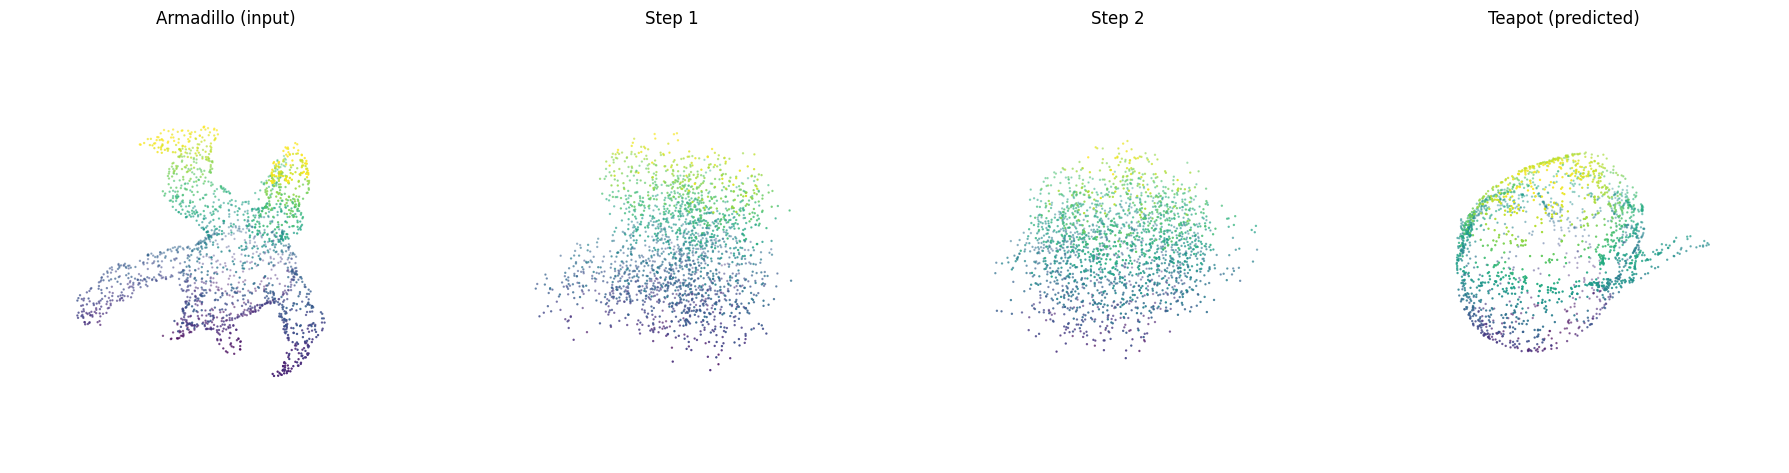

In [4]:
from armadillo.utils import visualize_transition, interpolate_pointclouds
from armadillo.dataset import load_obj_pointcloud, normalize_pointcloud

src_pts  = normalize_pointcloud(load_obj_pointcloud(str(ARMADILLO_PATH), N_POINTS))
pred_pts = transform_mesh(ARMADILLO_PATH, model, DEVICE)

steps = interpolate_pointclouds(src_pts, pred_pts, steps=4)

visualize_transition(
    steps,
    titles=["Armadillo (input)", "Step 1", "Step 2", "Teapot (predicted)"]
)

In [5]:
from armadillo.utils import visualize_transition_3d

visualize_transition_3d(
    steps,
    titles=["Armadillo (input)", "Step 1", "Step 2", "Teapot (predicted)"]
)

In [6]:
from evaluate import evaluate_all
from armadillo.utils import load_mesh, pointcloud_to_mesh

teapot_mesh = load_mesh(str(TEAPOT_PATH))

pred_pts    = transform_mesh(ARMADILLO_PATH, model, DEVICE)
pred_mesh   = pointcloud_to_mesh(pred_pts)

metrics_arm = evaluate_all(pred_mesh, teapot_mesh, n_points=N_POINTS, resolution=64)

print("=== Armadillo flow — metrics ===")
print(f"  IoU     : {metrics_arm['iou']:.4f}")
print(f"  Dice    : {metrics_arm['dice']:.4f}")
print(f"  Chamfer : {metrics_arm['chamfer']:.6f}")

=== Armadillo flow — metrics ===
  IoU     : 0.7452
  Dice    : 0.8540
  Chamfer : 3.226125


# Asian Dragon -> Teapot

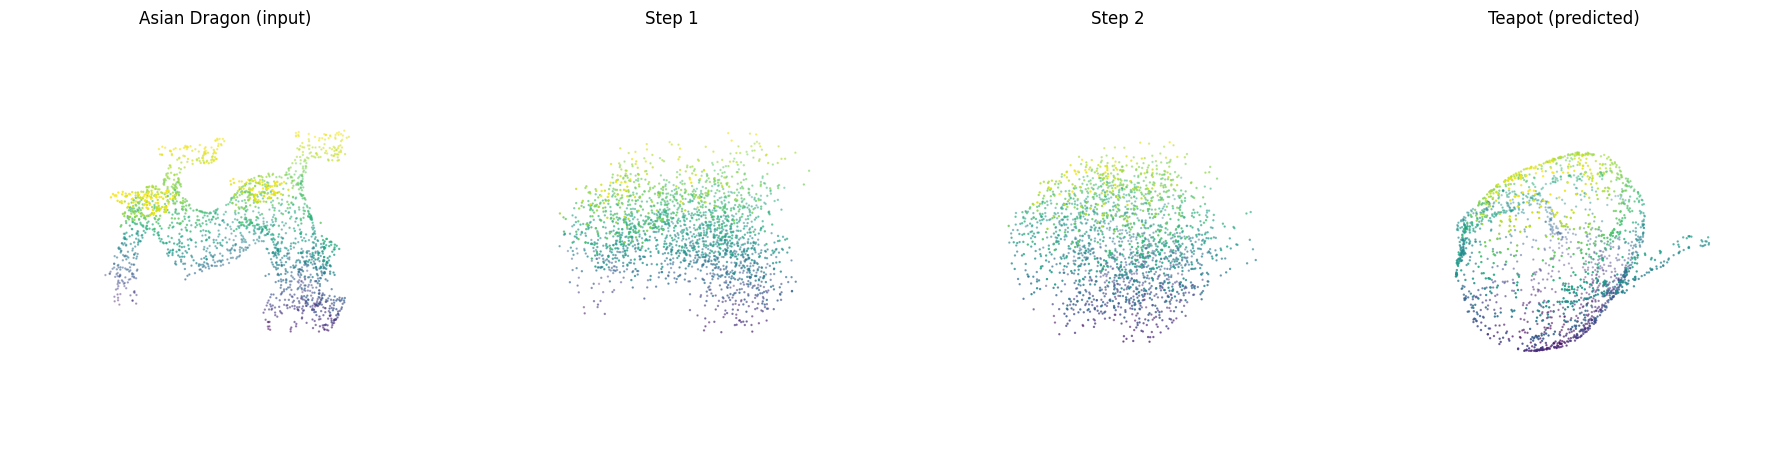

In [7]:
pred_pts_dragon = transform_mesh(ASIAN_DRAG_PATH, model, DEVICE)

src_dragon  = normalize_pointcloud(load_obj_pointcloud(str(ASIAN_DRAG_PATH), N_POINTS))
steps_dragon = interpolate_pointclouds(src_dragon, pred_pts_dragon, steps=4)

visualize_transition(
    steps_dragon,
    titles=["Asian Dragon (input)", "Step 1", "Step 2", "Teapot (predicted)"]
)

In [8]:
visualize_transition_3d(
    steps_dragon,
    titles=["Asian Dragon (input)", "Step 1", "Step 2", "Teapot (predicted)"]
)

In [9]:
pred_mesh_dragon = pointcloud_to_mesh(pred_pts_dragon)
metrics_drag     = evaluate_all(pred_mesh_dragon, teapot_mesh, n_points=N_POINTS, resolution=64)

print("=== Armadillo flow @ Asian Dragon — metrics ===")
print(f"  IoU     : {metrics_drag['iou']:.4f}")
print(f"  Dice    : {metrics_drag['dice']:.4f}")
print(f"  Chamfer : {metrics_drag['chamfer']:.6f}")

=== Armadillo flow @ Asian Dragon — metrics ===
  IoU     : 0.7867
  Dice    : 0.8806
  Chamfer : 3.195061


In [10]:
import pandas as pd

rows = [
    {"Method": "armadillo flow",             **metrics_arm},
    {"Method": "armadillo flow asian dragon", **metrics_drag},
]

df = pd.DataFrame(rows).set_index("Method")
df.columns = ["IoU", "Dice", "Chamfer"]
df = df.round({"IoU": 4, "Dice": 4, "Chamfer": 6})

print(df.to_string())

                                IoU    Dice   Chamfer
Method                                               
armadillo flow               0.7452  0.8540  3.226125
armadillo flow asian dragon  0.7867  0.8806  3.195061


In [11]:
from pathlib import Path
from armadillo.utils import pointcloud_to_mesh

RESULTS_DIR = Path("results/armadillo")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

pred_arm_pts    = transform_mesh(ARMADILLO_PATH, model, DEVICE)
pred_dragon_pts = transform_mesh(ASIAN_DRAG_PATH, model, DEVICE)

mesh_arm_pred    = pointcloud_to_mesh(pred_arm_pts)
mesh_dragon_pred = pointcloud_to_mesh(pred_dragon_pts)

teapot_pts = normalize_pointcloud(load_obj_pointcloud(str(TEAPOT_PATH), N_POINTS))

In [12]:
import plotly.graph_objects as go

def show_pointcloud(points: np.ndarray, title: str = "", point_size: int = 2):
    fig = go.Figure(go.Scatter3d(
        x=points[:, 0], y=points[:, 1], z=points[:, 2],
        mode="markers",
        marker=dict(size=point_size, color=points[:, 2], colorscale="Viridis"),
    ))
    fig.update_layout(title=title, height=600, margin=dict(l=0, r=0, t=40, b=0))
    fig.show()

show_pointcloud(pred_arm_pts,    "Armadillo predicted")
show_pointcloud(pred_dragon_pts, "Asian Dragon predicted")
show_pointcloud(teapot_pts,      "Teapot (target)")